In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras.models import load_model
from keras import layers, Model, ops
from keras.optimizers import Adam, Adadelta
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import gensim
# Necesario para TextVectorization y tf.data
import tensorflow as tf
import matplotlib.pyplot as plt
from typing import Literal, Optional


In [2]:
np.random.seed(42)


In [3]:
print(keras.config.backend())


torch


In [4]:
data_path = "../data"
processed_dir = os.path.join(data_path, "processed")
augmented_dir = os.path.join(data_path, "augmented")

models_dir = "../models"
word2vec_path = os.path.join(models_dir, "spanish_word2vec", "spanish_word2vec.wordvectors")
siamese_lstm_path = os.path.join(models_dir, "siamese_lstm.keras")
embedding_path = os.path.join(models_dir, "embedding_matrix.npy")


In [5]:
EMBED_DIM = 400
HIDDEN_DIM = 64
BATCH_SIZE = 64
matt = "toda la clase"


In [6]:
use_augmented_data = True

if use_augmented_data:
    MAX_LEN = 26
    train_dir = augmented_dir
else:
    MAX_LEN = 25
    train_dir = processed_dir

In [7]:
splits = [
	("train", train_dir), 
	("dev", processed_dir), 
	("test", processed_dir)
]

datasets = {}
for split, dir in splits:
	path = os.path.join(dir, f"stsb-es-{split}.csv")
	datasets[split] = pd.read_csv(path)

train_df = datasets["train"]
dev_df = datasets["dev"]
test_df = datasets["test"]

In [8]:
print("Train length:", len(train_df))
print("Dev length:", len(dev_df))
print("Test length:", len(test_df))

Train length: 15242
Dev length: 1500
Test length: 1379


In [9]:
all_sentences = list(train_df["sentence1"]) + list(train_df["sentence2"])

vectorizer = layers.TextVectorization(
	max_tokens=None,
	output_mode="int",
	output_sequence_length=MAX_LEN,
)

vectorizer.adapt(all_sentences)

vocab = vectorizer.get_vocabulary()
word2idx = {word: idx for idx, word in enumerate(vocab)}
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 15871


In [10]:
def load_gensim_embeddings(path, word2idx: dict, embed_dim: int):
	wv = gensim.models.KeyedVectors.load(path, mmap="r")
	embedding_matrix = np.random.uniform(-0.05, 0.05, (len(word2idx), embed_dim))
	# El índice 0 se utiliza como padding token, por lo que tiene un vector de ceros, para indicar que no contribuye
	embedding_matrix[0] = 0
	found = 0
	for word, idx in word2idx.items():
		if word in wv.key_to_index:
			embedding_matrix[idx] = wv[word]
			found += 1
	print(f"Found {found}/{len(word2idx)} words.")
	return embedding_matrix

embedding_matrix = load_gensim_embeddings(word2vec_path, word2idx, EMBED_DIM)
np.save(embedding_path, embedding_matrix)
print(f"Embedding matrix saved to {embedding_path}")


Found 15419/15871 words.
Embedding matrix saved to ../models\embedding_matrix.npy


In [11]:
def encode_sentences(sent1, sent2, label):
	seq1 = vectorizer(sent1)
	seq2 = vectorizer(sent2)
	return seq1, seq2, label

# def encode_sentence(sentence: str):
#     vectorized = vectorizer(np.array([sentence]))
#     return np.array(vectorized[0])


In [12]:
def create_dataset(df: pd.DataFrame, batch_size: int, shuffle: bool=False):
	sent1 = tf.constant(df["sentence1"].values, dtype=tf.string)
	sent2 = tf.constant(df["sentence2"].values, dtype=tf.string)
	labels = tf.constant(df["score_norm"].values, dtype=tf.float32)
	dataset = tf.data.Dataset.from_tensor_slices((sent1, sent2, labels))
	
	dataset = dataset.map(encode_sentences, num_parallel_calls=tf.data.AUTOTUNE)

	dataset = dataset.map(
		lambda sent1, sent2, labels: ((sent1, sent2), labels),
		num_parallel_calls=tf.data.AUTOTUNE
	)

	if shuffle:
		dataset = dataset.shuffle(len(df))

	dataset = dataset.batch(batch_size)
	dataset = dataset.prefetch(tf.data.AUTOTUNE)
	
	return dataset

# def create_dataset(df, encode_fn, shuffle: bool = False):
#     sent1 = np.array([encode_fn(sent) for sent in df["sentence1"].values])
#     sent2 = np.array([encode_fn(sent) for sent in df["sentence2"].values])
#     labels = df["score_norm"].values.astype(np.float32)
	
#     if shuffle:
#         idx = np.arange(len(labels))
#         np.random.shuffle(idx)
#         sent1 = sent1[idx]
#         sent2 = sent2[idx]
#         labels = labels[idx]

#     return (sent1, sent2), labels

In [13]:
train_dataset = create_dataset(train_df, BATCH_SIZE, shuffle=False)
dev_dataset = create_dataset(dev_df, BATCH_SIZE)
test_dataset = create_dataset(test_df, BATCH_SIZE)

# train_dataset = create_dataset(train_df, encode_sentence, shuffle=False)
# dev_dataset = create_dataset(dev_df, encode_sentence)
# test_dataset = create_dataset(test_df, encode_sentence)


In [14]:
def l2_normalize(x, axis=1):
	norm = ops.sqrt(ops.sum(ops.square(x), axis=axis, keepdims=True))
	return x / (norm + 1e-8)

def cosine_similarity(x, y):
	x_norm = l2_normalize(x)
	y_norm = l2_normalize(y)
	return ops.sum(x_norm * y_norm, axis=1, keepdims=True)

def manhattan_similarity(x, y):
	distance = ops.sum(ops.abs(x - y), axis=1, keepdims=True)
	return ops.exp(-distance)

In [15]:
class SiameseLSTM(Model):
	def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, embedding_matrix: Optional[np.ndarray] = None, pooling: Literal["last", "mean"] = "mean", similarity: Literal["manhattan", "cosine"] = "cosine", dropout: float = 0.3, bidirectional: bool = False, name="siamese_lstm", **kwargs):
		super().__init__(name=name, **kwargs)

		self.vocab_size = vocab_size
		self.embedding_dim = embedding_dim
		self.hidden_dim = hidden_dim
		self.pooling = pooling
		self.similarity = similarity
		self.dropout = dropout
		self.bidirectional = bidirectional

		if embedding_matrix is not None:
			initializer = keras.initializers.Constant(embedding_matrix)
			trainable = False
		else:
			initializer = "uniform"
			trainable = True	

		self.embedding = layers.Embedding(
			input_dim=vocab_size,
			output_dim=embedding_dim,
			embeddings_initializer=initializer,
			trainable=trainable,
			mask_zero=True,
			name="embedding"
		)

		lstm_layer = layers.LSTM(
			hidden_dim,
			return_sequences=True,
			dropout=dropout,
			recurrent_dropout=dropout,
		)

		if bidirectional:
			self.lstm = layers.Bidirectional(lstm_layer, name="bilstm")
		else:
			self.lstm = lstm_layer

	def masked_mean_pool(self, hidden_states, mask):
		# mask (batch, seq_len)
		mask = ops.cast(mask, hidden_states.dtype)

		# Expandir máscara para que coincida con el estado oculto
		# (batch, seq_len) -> (batch, seq_len, 1)
		mask = ops.expand_dims(mask, axis=-1)

		# hidden_states (batch, seq_len, 1)
		# mask (batch, seq_len, hidden_dim)
		masked_hidden = hidden_states * mask

		sum_hidden = ops.sum(masked_hidden, axis=1)
		# Contar el número de palabras sin padding
		token_count = ops.sum(mask, axis=1)

		return sum_hidden / (token_count + 1e-8)

	def pool(self, x, mask):
		if self.pooling == "last":
			# Si hay padding, se copia el estado anterior
			return x[:, -1, :]
		elif self.pooling == "mean":
			return self.masked_mean_pool(x, mask)
	
	def compute_similarity(self, x, y):
		if self.similarity == "manhattan":
			return manhattan_similarity(x, y)
		elif self.similarity == "cosine":
			return cosine_similarity(x, y)
		
	def call(self, inputs, training=False):
		sent1, sent2 = inputs

		emb1 = self.embedding(sent1)
		emb2 = self.embedding(sent2)

		mask1 = self.embedding.compute_mask(sent1)
		mask2 = self.embedding.compute_mask(sent2)

		lstm_out1 = self.lstm(emb1, training=training)
		lstm_out2 = self.lstm(emb2, training=training)	

		vec1 = self.pool(lstm_out1, mask1)
		vec2 = self.pool(lstm_out2, mask2)
	
		similarity = self.compute_similarity(vec1, vec2)
		
		return similarity
	
	def get_config(self):
		config = super().get_config()
		config.update({
			"vocab_size": self.vocab_size,
			"embedding_dim": self.embedding_dim,
			"hidden_dim": self.hidden_dim,
			"pooling": self.pooling,
			"similarity": self.similarity,
			"bidirectional": self.bidirectional,
		})
		return config
	
	@classmethod
	def from_config(cls, config):
		return cls(**config, embedding_matrix=None)
	
	def get_head_model(self):
		input_sent = layers.Input(shape=(None,), dtype=tf.int32, name="input_sentence")
		emb = self.embedding(input_sent)
		mask = self.embedding.compute_mask(input_sent)
		lstm_out = self.lstm(emb, training=False)
		vec = self.pool(lstm_out, mask)
		return Model(inputs=input_sent, outputs=vec, name="siamese_head")
	

In [16]:
embedding_matrix = np.load(embedding_path)


In [17]:
model = SiameseLSTM(
    len(vocab), 
    EMBED_DIM, 
    HIDDEN_DIM, 
    embedding_matrix, 
    pooling="mean",
    similarity="manhattan",
    bidirectional=True
)


In [18]:
head_model = model.get_head_model()
head_model.summary()


Model: "siamese_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sentence      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ input_sentence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 400) │  6,348,400 │ input_sentence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, None)      │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, None, 128) │    238,080 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, None, 1)   │          0 │ cast[0][0]        │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, None, 128) │          0 │ bilstm[0][0],     │
│                     │                   │            │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_1 (Sum)         │ (None, 1)         │          0 │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, 128)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ sum_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 128)       │          0 │ sum[0][0],        │
│ (TrueDivide)        │                   │            │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,586,480 (25.13 MB)

 Trainable params: 238,080 (930.00 KB)

 Non-trainable params: 6,348,400 (24.22 MB)

In [19]:
dummy_sent1 = tf.zeros((1, MAX_LEN), dtype=tf.int32)
dummy_sent2 = tf.zeros((1, MAX_LEN), dtype=tf.int32)

model((dummy_sent1, dummy_sent2))

model.summary()

Model: "siamese_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 400)      │     6,348,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, None, 128)      │       238,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,586,480 (25.13 MB)

 Trainable params: 238,080 (930.00 KB)

 Non-trainable params: 6,348,400 (24.22 MB)

In [20]:
# def pearson_correlation(y_true, y_pred):    
# 	# Medias
# 	mean_true = np.mean(y_true)
# 	mean_pred = np.mean(y_pred)
	
# 	# Covarianza
# 	cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
	
# 	# Desviaciones estándar
# 	std_true = np.std(y_true)
# 	std_pred = np.std(y_pred)
	
# 	# Pearson
# 	return cov / (std_true * std_pred + 1e-8)


In [21]:
# optimizer = Adadelta(learning_rate=1.0, clipnorm=1.0)
optimizer=Adam(learning_rate=1e-3, clipnorm=1.0)

# Rangos óptimos
# MSE = 0.1-0.2
# MAE = 0.25-0.35
model.compile(
	optimizer=optimizer,
	loss="mse",
	metrics=["mae"]
)

In [22]:
callbacks = [
	EarlyStopping(
		monitor="val_loss",
		patience=5,
		restore_best_weights=True,
	),
	ModelCheckpoint(
		filepath=siamese_lstm_path,
		monitor="val_loss",
		save_best_only=True,
	),
	ReduceLROnPlateau(
		monitor="val_loss",
		factor=0.5,
		patience=3,
		min_lr=1e-6,
	)
]


In [23]:
for (s1, s2), y in train_dataset.take(1):
	print("s1:", s1.shape)
	print("s2:", s2.shape)
	print("y:", y.shape)

s1: (64, 26)
s2: (64, 26)
y: (64,)


In [24]:
history = model.fit(
	train_dataset,
	validation_data=dev_dataset,
	epochs=20,
	callbacks=callbacks
)


Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - loss: 0.3202 - mae: 0.4857 - val_loss: 0.1399 - val_mae: 0.2965 - learning_rate: 0.0010
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 224s 937ms/step - loss: 0.1437 - mae: 0.3123 - val_loss: 0.0900 - val_mae: 0.2424 - learning_rate: 0.0010
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 228s 956ms/step - loss: 0.0952 - mae: 0.2542 - val_loss: 0.0794 - val_mae: 0.2286 - learning_rate: 0.0010
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 237s 992ms/step - loss: 0.0796 - mae: 0.2320 - val_loss: 0.0727 - val_mae: 0.2192 - learning_rate: 0.0010
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 232s 969ms/step - loss: 0.0703 - mae: 0.2181 - val_loss: 0.0713 - val_mae: 0.2175 - learning_rate: 0.0010
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - loss: 0.0649 - mae: 0.2091 - val_loss: 0.0705 - val_mae: 0.2165 - learning_rate: 0.0010
Epoch 7/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - loss: 0.0609 - mae: 0.2034 - val_loss: 0.0691 - val_mae: 0.2140 - learning_

In [25]:
custom_objects={
	"SiameseLSTM": SiameseLSTM,
	"l2_normalize": l2_normalize,
	"manhattan_similarity": manhattan_similarity,
	"cosine_similarity": cosine_similarity,
}

model = load_model(
	siamese_lstm_path,
	custom_objects=custom_objects,
	compile=False
)

model.embedding.set_weights([embedding_matrix])


In [26]:
def plot_history(history):
	hist = history.history

	plt.figure(figsize=(18,5))

	plt.subplot(1,3,1)
	plt.plot(hist["loss"], label="train")
	plt.plot(hist["val_loss"], label="validation")

	best_val_loss = np.min(hist["val_loss"])
	best_epoch_loss = np.argmin(hist["val_loss"])
	plt.scatter(best_epoch_loss, best_val_loss, color='red', s=100, label=f"best val_loss: {best_val_loss:.6f}")
	plt.title("Loss")
	plt.xlabel("Epoch")
	plt.ylabel("MSE Loss")
	plt.legend()

	plt.subplot(1,3,2)
	plt.plot(hist["mae"], label="train")
	plt.plot(hist["val_mae"], label="validation")

	best_val_mae = np.min(hist["val_mae"])
	best_epoch_mae = np.argmin(hist["val_mae"])
	plt.scatter(best_epoch_mae, best_val_mae, color='red', s=100, label=f"best val_mae: {best_val_mae:.6f}")
	plt.title("MAE")
	plt.xlabel("Epoch")
	plt.ylabel("Mean Absolute Error")
	plt.legend()

	plt.tight_layout()
	plt.show()
	
	print(
		f"Best Val Loss (MSE): {best_val_loss:.6f} (epoch {best_epoch_loss + 1}) | "
		f"Best Val MAE: {best_val_mae:.6f} (epoch {best_epoch_mae + 1})"
	)
	

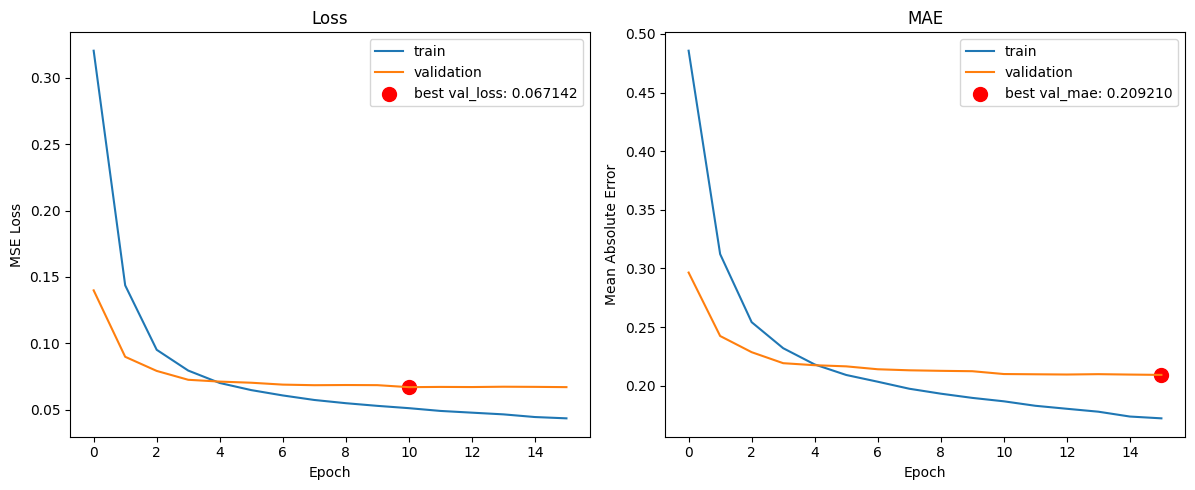

Best Val Loss (MSE): 0.067142 (epoch 11) | Best Val MAE: 0.209210 (epoch 16)


In [27]:
plot_history(history)

In [28]:
def evaluate_model(model: Model, dataset: tf.data.Dataset):
	y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)
	
	y_pred = model.predict(dataset).flatten()
	
	# Comprueba si la relación entre las predicciones y las etiquetas sigue una línea recta.
	# - 1.0 --> correlación positiva perfecta
	# - 0.0 --> sin correlación
	# - -1.0 --> correlación negativa perfecta
	pearson, _ = pearsonr(y_true, y_pred)
	# Compara el orden de las predicciones y los valores reales.
	spearman, _ = spearmanr(y_true, y_pred)
	mse = np.mean((y_true - y_pred) ** 2)
	mae = np.mean(np.abs(y_true - y_pred))

	print(
		f"Pearson: {pearson:.4f} | "
		f"Spearman: {spearman:.4f} | "
		f"MSE: {mse:.6f} | "
		f"MAE: {mae:.6f}"
	)
	

In [29]:
evaluate_model(model, test_dataset)


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 505ms/step
Pearson: 0.5021 | Spearman: 0.4946 | MSE: 0.073060 | MAE: 0.213338


In [30]:
sentences = [
	"Me encanta programar en Python.",
	"El perro corre rápido por el parque."
]

sentence_tensor = vectorizer(sentences)
print("Sentence tensor shape:", sentence_tensor.shape)

vecs = head_model(sentence_tensor)
print("Embeddings shape:", vecs.shape)

for i, sentence in enumerate(sentences):
	print(f"\nSentence {i+1}: '{sentence}'")
	print("Sentence tensor:")
	print(sentence_tensor[i])

sim = cosine_similarity(vecs[0].unsqueeze(0), vecs[1].unsqueeze(0))
print("Cosine similarity:", sim.item())

Sentence tensor shape: torch.Size([2, 26])
Embeddings shape: torch.Size([2, 128])

Sentence 1: 'Me encanta programar en Python.'
Sentence tensor:
tensor([ 521, 8804,    1,    5, 8501,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0], device='cuda:0')

Sentence 2: 'El perro corre rápido por el parque.'
Sentence tensor:
tensor([   4,   30,  209, 3751,   16,    4, 1171,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0], device='cuda:0')
Cosine similarity: 0.7939796447753906


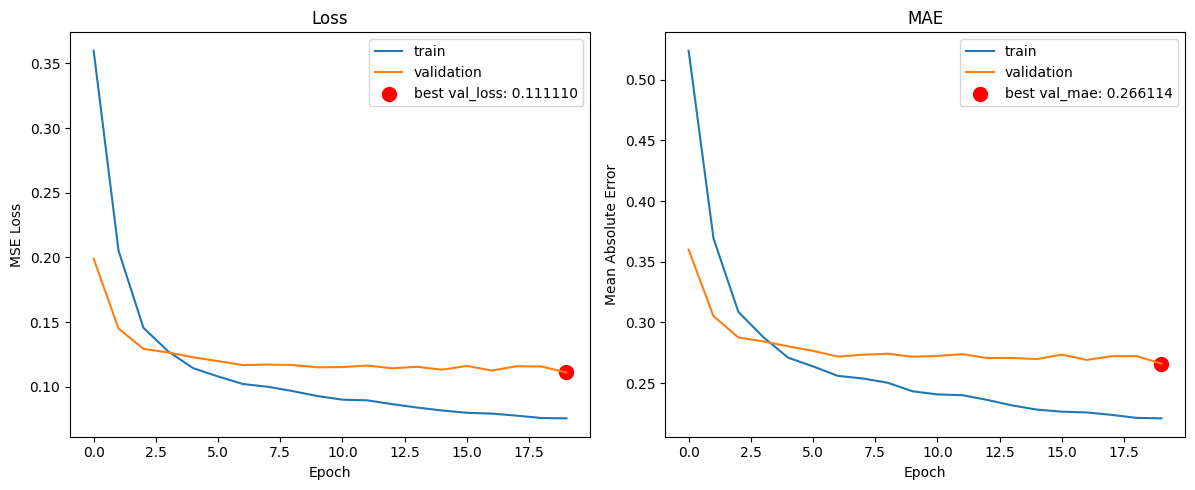

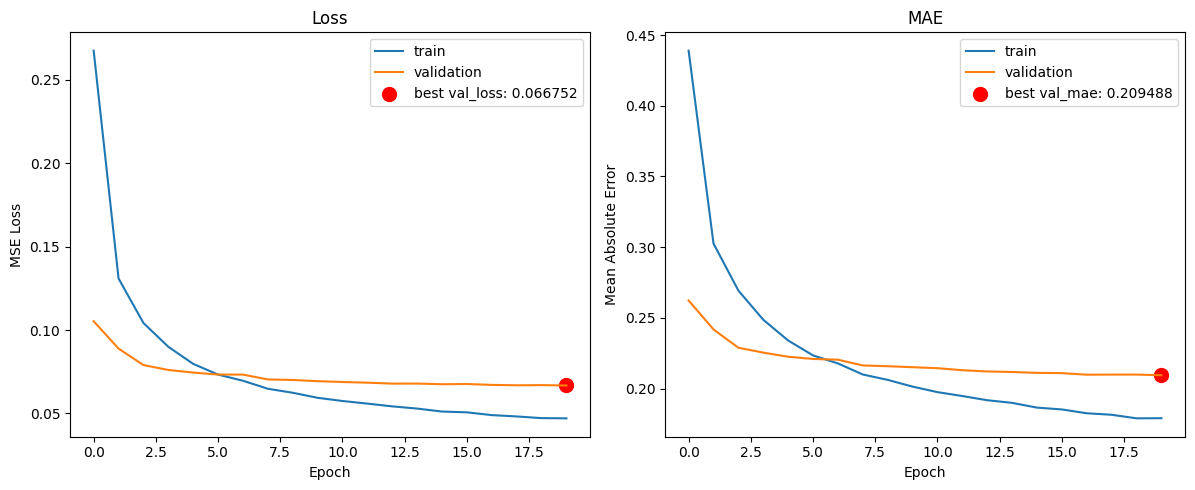

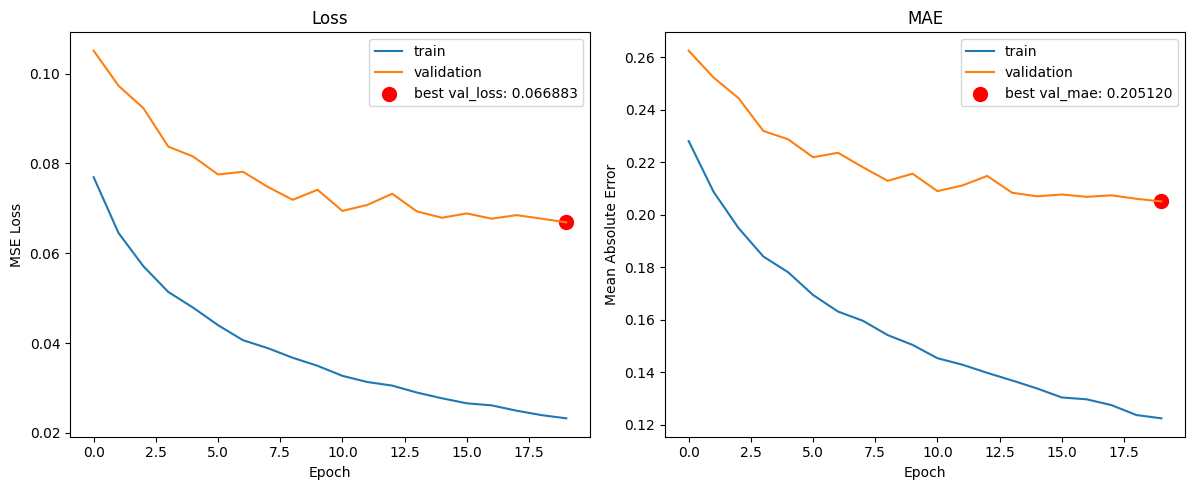



| Settings | Hidden State | Seq Length | Train Loss | Train MAE | Val Loss | Val MAE | Test Pearson | Test Spearman | Test MSE | Test MAE | Train Time |
|---------------------|-------------|-----------|------------|-----------|----------|---------|--------------|---------------|----------|----------|------------|
| LSTM + Last Hidden State + Manhattan | 64 | 25 | 0.0757 | 0.2210 | 0.1111 | 0.2661 | 0.3959 | 0.3913 | 0.114060 | 0.267243 | 16m 8.9s |
| LSTM + Mean Pooling + Manhattan | 64 | 25 | 0.0470 | 0.1791 | **0.0668** | 0.2095 | 0.5382 | 0.5215 | **0.069820** | **0.209331** | 16m 24.8s |
| **LSTM + Mean Pooling + Cosine** | 64 | 25 | **0.0232** | **0.1224** | **0.0669** | **0.2051** | **0.6425** | **0.6277** | **0.070664** | **0.207292** | 16m 47.2s |



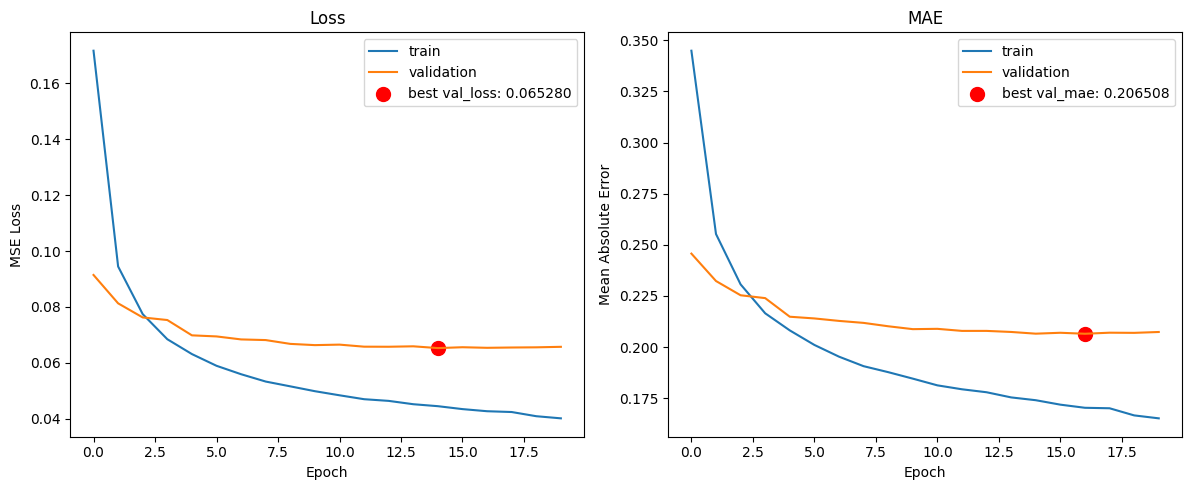

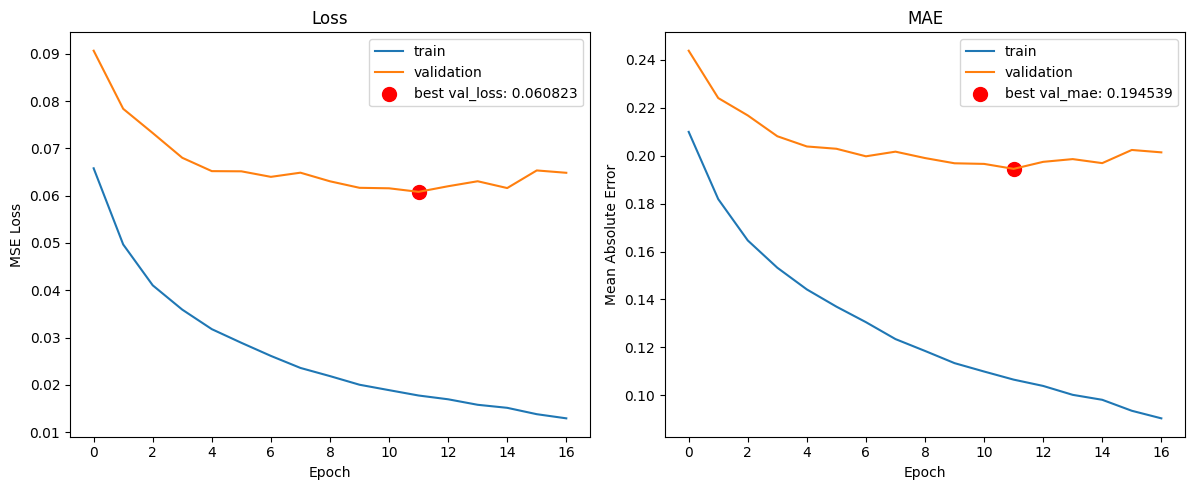

| Settings | Hidden State | Seq Length | Train Loss | Train MAE | Val Loss | Val MAE | Test Pearson | Test Spearman | Test MSE | Test MAE | Train Time |
|---------------------|-------------|-----------|------------|-----------|----------|---------|--------------|---------------|----------|----------|------------|
| LSTM + Mean Pooling + Manhattan | 64 | 26 | 0.0445 | 0.1740 | 0.0653 | 0.2065 | 0.5437 | 0.5250 | 0.069002 | 0.209312 | 39m 12.8s |
| BiLSTM + Mean Pooling + Cosine | 64 * 2 | 26 | 0.0177 | 0.1065 | 0.0608 | 0.1945 | 0.6659 | 0.6580 | 0.063016 | 0.193822 | 61m 22.6s |
